# Milestone 2

In [6]:
import os
import glob
import librosa
import librosa.display
import torch
import torchaudio
import random
import numpy as np
import pandas as pd
from tqdm import tqdm
from pathlib import Path
import matplotlib.pyplot as plt

In [ ]:
DATA_ROOT = Path('../../data/raw/messy_mashup/genres_stems')

- What is the mean duration (in seconds) of the Jazz genre stems in train dataset?

In [ ]:
durations=[]
jazz_path = DATA_ROOT / "jazz"
for song in tqdm(os.listdir(jazz_path)):
    song_path = jazz_path / song


    for stem_file in os.listdir(song_path):
        stem_path = song_path / stem_file

        y, sr = torchaudio.load(stem_path)
        duration = librosa.get_duration(y=y.numpy()[0], sr=sr)
        durations.append(duration)

mean_duration = np.mean(durations)
print(f"Mean duration of Jazz genre stems in train dataset: {mean_duration} seconds")

100%|██████████| 100/100 [00:06<00:00, 16.18it/s]

Mean duration of Jazz genre stems in train dataset: 30.032979591836728 seconds


- What are the unique sample rates present in the dataset? Enter your answer as a comma separated list. Example: [40000, 50000, 60000]

In [17]:
sample_rates = set()

for genre in tqdm(os.listdir(DATA_ROOT)):
    genre_path = DATA_ROOT / genre

    for song in os.listdir(genre_path):
        song_path = genre_path / song

        for stem_file in os.listdir(song_path):
            stem_path = song_path / stem_file

            y, sr = torchaudio.load(stem_path)
            sample_rates.add(sr)

print(f"Unique sample rates present in the dataset: {sorted(sample_rates)}")

100%|██████████| 10/10 [01:59<00:00, 11.97s/it]

Unique sample rates present in the dataset: [44100]


- How many corrupted or zero-byte audio files are present in the train dataset?

In [27]:
corrupted_files = []

for genre in tqdm(os.listdir(DATA_ROOT)):
    genre_path = DATA_ROOT / genre

    for song in os.listdir(genre_path):
        song_path = genre_path / song

        for stem_file in os.listdir(song_path):
            stem_path = song_path / stem_file

            # Zero byte check
            if os.path.getsize(stem_path) == 0:
                corrupted_files.append(stem_path)
                continue

            # Checking loading file
            try:
                y, sr = torchaudio.load(stem_path)
            except Exception as e:
                corrupted_files.append(stem_path)

print(f"Number of corrupted or zero-byte audio files in train dataset: {len(corrupted_files)}")

100%|██████████| 10/10 [02:42<00:00, 16.22s/it]

Number of corrupted or zero-byte audio files in train dataset: 0


- What is the average peak amplitude (in dB) for vocal stems in train dataset? 

In [ ]:
peak_amplitudes = []

for genre in tqdm(os.listdir(DATA_ROOT)):
    genre_path = DATA_ROOT / genre

    for song in os.listdir(genre_path):
        song_path = genre_path / song

        for stem_file in os.listdir(song_path):
            if "vocals" in stem_file.lower():
                stem_path = song_path / stem_file

                y, sr = torchaudio.load(stem_path)
                peak_amplitude=torch.max(torch.abs(y))
                # Convert to dB
                peak_amplitude_db = 20 * torch.log10(peak_amplitude)
                peak_amplitudes.append(peak_amplitude_db)

average_peak_amplitude_db = np.mean(peak_amplitudes)
print(f"Average peak amplitude for vocal stems in train dataset: {average_peak_amplitude_db} dB")


100%|██████████| 10/10 [00:59<00:00,  5.90s/it]

Average peak amplitude for vocal stems in train dataset: -12.478583335876465 dB


- What is the mean spectral centroid for 'blues' genre in the train dataset?  

In [33]:
spectral_centroids = {}

for genre in tqdm(os.listdir(DATA_ROOT)):
    genre_path = DATA_ROOT / genre

    for song in os.listdir(genre_path):
        song_path = genre_path / song

        for stem_file in os.listdir(song_path):
            stem_path = song_path / stem_file

            y, sr = torchaudio.load(stem_path)
            y=y.numpy() # Convert to numpy array for librosa
            spectral_centroid = librosa.feature.spectral_centroid(y=y, sr=sr)
            mean_spectral_centroid = np.mean(spectral_centroid)

            try:
                spectral_centroids[genre].append(mean_spectral_centroid)
            except KeyError:
                spectral_centroids[genre] = [mean_spectral_centroid]

print(f"Mean spectral centroid for 'blues' genre in train dataset: {np.mean(spectral_centroids['blues'])} Hz")

100%|██████████| 10/10 [15:08<00:00, 90.86s/it]

Mean spectral centroid for 'blues' genre in train dataset: 2317.2998449319743 Hz


- Which genre in the train dataset has the highest mean spectral centroid?  

In [34]:
mean_centroids = {genre: np.mean(centroids) for genre, centroids in spectral_centroids.items()}

highest_centroid_genre = max(mean_centroids, key=mean_centroids.get)
print(f"Genre with highest mean spectral centroid: {highest_centroid_genre} ({mean_centroids[highest_centroid_genre]} Hz)")

Genre with highest mean spectral centroid: metal (2589.463214151149 Hz)


- How many stem audio files in the train dataset contain silence in the first 0.5 seconds?  

In [35]:
silence_count = 0

for genre in tqdm(os.listdir(DATA_ROOT)):
    genre_path = DATA_ROOT / genre

    for song in os.listdir(genre_path):
        song_path = genre_path / song

        for stem_file in os.listdir(song_path):
            stem_path = song_path / stem_file

            y, sr = torchaudio.load(stem_path)
            
            first_half_second = y[:, :int(0.5 * sr)]
            if torch.all(first_half_second == 0):
                silence_count += 1

print(silence_count)

100%|██████████| 10/10 [03:16<00:00, 19.70s/it]

126


### Paste the following python code in a Kaggle notebook. Complete the code as instructed in comments and answer the questions that follow.

/tmp/ipykernel_47205/3601079831.py:24: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  return [float(tempo), spec_cent, zcr, rolloff]


Validation Macro F1 Score: 0.2284

Detailed Classification Report:
              precision    recall  f1-score   support

       blues       0.25      0.40      0.31        10
   classical       0.22      0.40      0.29        10
     country       0.38      0.30      0.33        10
       disco       0.22      0.60      0.32        10
      hiphop       0.60      0.30      0.40        10
        jazz       0.20      0.10      0.13        10
       metal       0.50      0.50      0.50        10
         pop       0.00      0.00      0.00        10
      reggae       0.00      0.00      0.00        10
        rock       0.00      0.00      0.00        10

    accuracy                           0.26       100
   macro avg       0.24      0.26      0.23       100
weighted avg       0.24      0.26      0.23       100



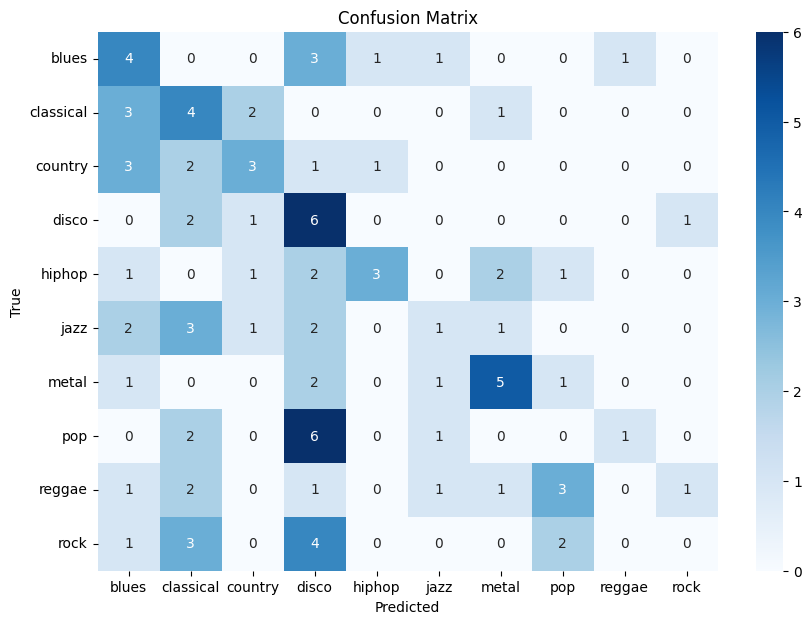

           TP  FP  FN  TN
blues       4  12   6  78
classical   4  14   6  76
country     3   5   7  85
disco       6  21   4  69
hiphop      3   2   7  88
jazz        1   4   9  86
metal       5   5   5  85
pop         0   7  10  83
reggae      0   2  10  88
rock        0   2  10  88


In [47]:
import os
import numpy as np
import pandas as pd
import librosa
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import f1_score, confusion_matrix, classification_report

# --- 1. Setup and Preprocessing ---
# ROOT = '/kaggle/input/jan-2026-dl-gen-ai-project/messy_mashup'
ROOT="../../data/raw/messy_mashup"
STEMS_PATH = os.path.join(ROOT, 'genres_stems')
GENRES = ["blues", "classical", "country", "disco", "hiphop", "jazz", "metal", "pop", "reggae", "rock"]

def extract_features(song_path):
    # Load 10s at 22050Hz
    y, sr = librosa.load(os.path.join(song_path, 'other.wav'), sr=22050, duration=10)
    tempo, _ = librosa.beat.beat_track(y=y, sr=sr)
    spec_cent = np.mean(librosa.feature.spectral_centroid(y=y, sr=sr))
    zcr = np.mean(librosa.feature.zero_crossing_rate(y))
    rolloff = np.mean(librosa.feature.spectral_rolloff(y=y, sr=sr))
    return [float(tempo), spec_cent, zcr, rolloff]

# --- 2. Data Preparation & Stratified Split ---
data = []
for g in GENRES:
    gp = os.path.join(STEMS_PATH, g)
    songs = [s for s in os.listdir(gp) if os.path.isdir(os.path.join(gp, s))]
    for s in songs[:50]: # Sampling 50 for speed; use all for final
        data.append({'path': os.path.join(gp, s), 'genre': g})

df = pd.DataFrame(data)
train_df, val_df = train_test_split(df, test_size=0.2, stratify=df['genre'], random_state=42)

# --- 3. Model Training (Decision Tree) ---
X_train = np.array([extract_features(p) for p in train_df['path']])
y_train = train_df['genre']
X_val = np.array([extract_features(p) for p in val_df['path']])
y_val = val_df['genre']

clf = DecisionTreeClassifier(max_depth=5, random_state=42)
clf.fit(X_train, y_train)

'''
YOUR CODE HERE

y_pred = # COMPUTE PREDICTED VALUES
macro_f1 = # COMPUTE VALIDATION MACRO F1 SCORE
cm = # COMPUTE CONFUSION MATRIX
cr = # COMPUTE CLASSIFICATION REPORT

'''

y_pred = clf.predict(X_val)
macro_f1 = f1_score(y_val, y_pred, average='macro')
cm = confusion_matrix(y_val, y_pred)
cr = classification_report(y_val, y_pred)


print(f"Validation Macro F1 Score: {macro_f1:.4f}\n")
print("Detailed Classification Report:")
print(cr)

'''
YOUR CODE HERE

Visualize the confusion matrix and compute TP, TN, FP, FN for all genres.
'''

plt.figure(figsize=(10, 7))
sns.heatmap(cm, annot=True, xticklabels=GENRES, yticklabels=GENRES, cmap='Blues')
plt.xlabel('Predicted')
plt.ylabel('True')
plt.title('Confusion Matrix')
plt.show()

metrics={}
for i, genre in enumerate(GENRES):
    TP = cm[i, i] # True Positives
    FP = cm[:, i].sum() - TP # False Positives
    FN = cm[i, :].sum() - TP # False Negatives
    TN = cm.sum() - (TP + FP + FN) # True Negatives
    metrics[genre] = {'TP': TP, 'FP': FP, 'FN': FN, 'TN': TN}

metrics_df = pd.DataFrame(metrics).transpose()
print(metrics_df)